# Bisection Method
Import required libraries

In [41]:
import matplotlib.pyplot as plt
import numpy as np

## BASIC BISECTION METHOD (without logging)

In [42]:
def bisect(f, a, b, delta):
    """
    Find a root of f(x) using the bisection method.
    Returns: (root, error_estimate, f(root))
    """
    # Ensure the tolerance is positive
    if delta <= 0:
        raise ValueError("Tolerance delta must be strictly positive.")

    # Evaluate the function at the endpoints
    ya = f(a)
    yb = f(b)

    # The bisection method requires a sign change.
    # If f(a) and f(b) have the same sign, the root is not guaranteed.
    if ya * yb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    # Compute the exact number of iterations needed to reach the desired interval width.
    # The formula comes from: (b-a) / 2^n < delta  =>  n > log2((b-a)/delta)
    # We add 1 to be safe and use rounding to convert to integer.
    max_iter = 1 + round((np.log(b - a) - np.log(delta)) / np.log(2))

    # Main loop: repeatedly halve the interval
    for _ in range(max_iter):
        c = (a + b) / 2.0      # Midpoint – current best guess
        yc = f(c)              # Function value at the midpoint

        # Decide which half contains the root
        if yc == 0:            # Exact root found
            a = c
            b = c
        elif yb * yc > 0:      # Root is in the left subinterval [a, c]
            b = c
            yb = yc            # Update the right endpoint value
        else:                  # Root is in the right subinterval [c, b]
            a = c
            ya = yc            # Update the left endpoint value

        # Early exit if the interval is already small enough
        if b - a < delta:
            break

    # Final refinement: compute the best estimate and its error
    c = (a + b) / 2.0
    err = np.abs(b - a)        # The absolute error bound is half the interval width
    yc = f(c)                  # Evaluate f at the final estimate

    return c, err, yc

## BISECTION WITH LOGGING (stores all iteration data)

In [43]:
def bisect_with_log(f, a, b, delta):
    """
    Bisection method with logging of each iteration.

    Returns:
        root     : final root estimate
        err      : final interval width (error bound)
        y_root   : f(root)
        history  : 2D numpy array with columns:
                   [iteration, a, b, c, f(c), error (b-a)]
    """
    # Same initial checks as before
    if delta <= 0:
        raise ValueError("Tolerance delta must be strictly positive.")

    ya = f(a)
    yb = f(b)
    if ya * yb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    # Pre‑calculate the maximum number of iterations needed
    max_iter = 1 + round((np.log(b - a) - np.log(delta)) / np.log(2))

    # Lists to accumulate the history
    iters = []
    a_hist = []
    b_hist = []
    c_hist = []
    fc_hist = []
    err_hist = []

    # Main loop – same as before, but with logging
    for k in range(max_iter):
        c = (a + b) / 2.0
        yc = f(c)
        err = b - a          # current interval width

        # Record this iteration
        iters.append(k + 1)       # 1‑based iteration number
        a_hist.append(a)
        b_hist.append(b)
        c_hist.append(c)
        fc_hist.append(yc)
        err_hist.append(err)

        # Update the bracket using the sign of f(c)
        if yc == 0:
            a = c
            b = c
        elif yb * yc > 0:
            b = c
            yb = yc
        else:
            a = c
            ya = yc

        # Exit early if the interval is sufficiently small
        if err < delta:
            break

    # Final refinement (after loop termination)
    c = (a + b) / 2.0
    yc = f(c)
    err = b - a

    # Append the final values to the history.
    # NOTE: The iteration number is set to max_iter (which might be one more
    #       than the actual number of iterations if we broke early).
    #       Alternatively, you could use len(iters)+1, but this keeps it simple.
    iters.append(max_iter)       # This may over‑count if we broke early
    a_hist.append(a)
    b_hist.append(b)
    c_hist.append(c)
    fc_hist.append(yc)
    err_hist.append(err)

    # Build a 2D NumPy array from the lists
    history = np.column_stack((iters, a_hist, b_hist, c_hist, fc_hist, err_hist))

    return c, err, yc, history


# Problem Statement.
Use the graphical approach to determine the drag coefficient $c$ needed for a parachutist of mass $m = 68.1$ $kg$ to have a velocity of $40$ $m/s$ after freefalling for time $t = 10$ $s$.

Note: The acceleration due to gravity is $9.81$ $m/s^2$

Solution. This problem can be solved by determining the root of

$f(c) = \frac{gm}{c}(1-exp^{-(c/m)t})-v$

using the parameters $t = 10$, $g = 9.81$, $v = 40$, and $m = 68.1$:

$f(c) = \frac{9.81(68.1)}{c}(1-exp^{-(c/68.1)10})-40$

In [44]:
def f(c):
    t = 10.0
    g = 9.81
    v = 40
    m = 68.1
    y = (g * m / c) * (1 - np.exp(-(c / m) * t)) - v
    return y

SET UP THE INITIAL BRACKET

CREATE THE FIRST PLOT (function curve only)

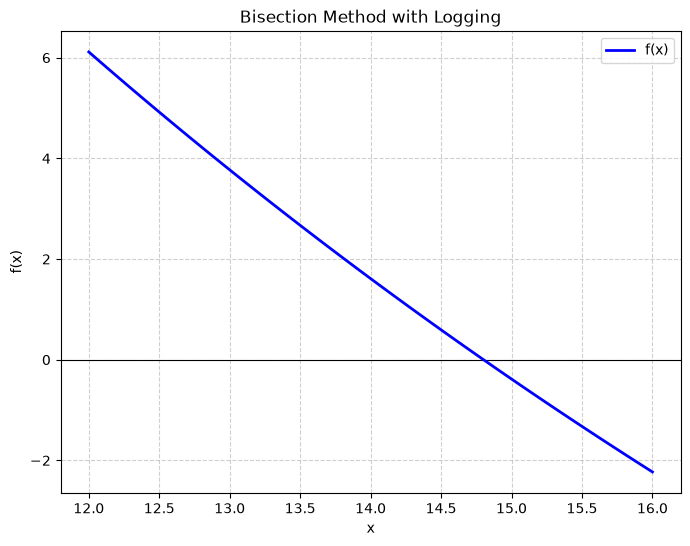

In [45]:
a = 12.0
b = 16.0

x_vals = np.linspace(a, b, 100)   # 100 points for a smooth curve
y_vals = f(x_vals)

plt.figure(figsize=(8, 6))

# Horizontal line at y=0 (the x‑axis)
plt.axhline(0, color='black', linewidth=0.8)

# Plot the function itself
plt.plot(x_vals, y_vals, label='f(x)', linewidth=2, color='blue')

# Add labels, title, grid, and legend
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Bisection Method with Logging')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

RUN THE BISECTION METHOD

In [46]:
a1, b1 = 12.0, 16.0
delta = 1e-6                    # Tolerance (desired interval width)

root1, error, f_root1 = bisect(f, a1, b1, delta)
print(f"Root found: {root1:.8f}")
print(f"Error estimate: {error:.2e}")
print(f"f(root) = {f_root1:.2e}")

Root found: 14.80113554
Error estimate: 9.54e-07
f(root) = 7.89e-07


CREATE THE SECOND PLOT WITH ROOT AND BRACKET

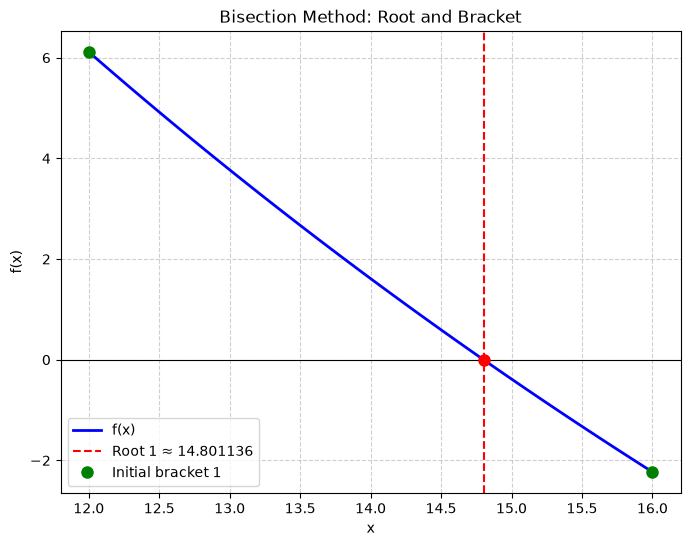

In [47]:
plt.figure(figsize=(8, 6))          # New figure
plt.axhline(0, color='black', linewidth=0.8)
plt.plot(x_vals, y_vals, label='f(x)', linewidth=2, color='blue')

# Add the found root as a red dashed vertical line and a red dot
plt.axvline(root1, color='red', linestyle='--', label=f'Root 1 ≈ {root1:.6f}')
plt.plot(root1, f(root1), 'ro', markersize=8)

# Mark the initial bracket endpoints as green circles
plt.plot(a1, f(a1), 'go', markersize=8, label='Initial bracket 1')
plt.plot(b1, f(b1), 'go', markersize=8)

# Labels and legend again
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Bisection Method: Root and Bracket')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

In [48]:
a, b = 12.0, 16.0
delta = 1e-6                    # Tolerance (desired interval width)

# Call the logging version of bisection
root, error, y_root, history = bisect_with_log(f, a, b, delta)

# Print the iteration history as a formatted table
print("\nIteration History:")
print("Iter\t a\t\t b\t\t c\t\t f(c)\t\t Error (b - a)")
print("-" * 80)
for row in history:
    # row[0] is iteration number, row[1]..row[5] are a, b, c, f(c), error
    print(f"{int(row[0]):2d}\t {row[1]:.6f}\t {row[2]:.6f}\t {row[3]:.6f}\t {row[4]:.6e}\t {row[5]:.6e}")

# Display summary results
print(f"\nRoot found: {root:.8f}")
print(f"Error estimate: {error:.2e}")
print(f"f(root) = {y_root:.2e}")
print(f"Log saved as numpy array (shape {history.shape}).")



Iteration History:
Iter	 a		 b		 c		 f(c)		 Error (b - a)
--------------------------------------------------------------------------------
 1	 12.000000	 16.000000	 14.000000	 1.611116e+00	 4.000000e+00
 2	 14.000000	 16.000000	 15.000000	 -3.844581e-01	 2.000000e+00
 3	 14.000000	 15.000000	 14.500000	 5.936984e-01	 1.000000e+00
 4	 14.500000	 15.000000	 14.750000	 9.982999e-02	 5.000000e-01
 5	 14.750000	 15.000000	 14.875000	 -1.434972e-01	 2.500000e-01
 6	 14.750000	 14.875000	 14.812500	 -2.213121e-02	 1.250000e-01
 7	 14.750000	 14.812500	 14.781250	 3.877477e-02	 6.250000e-02
 8	 14.781250	 14.812500	 14.796875	 8.303157e-03	 3.125000e-02
 9	 14.796875	 14.812500	 14.804688	 -6.918677e-03	 1.562500e-02
10	 14.796875	 14.804688	 14.800781	 6.910763e-04	 7.812500e-03
11	 14.800781	 14.804688	 14.802734	 -3.114091e-03	 3.906250e-03
12	 14.800781	 14.802734	 14.801758	 -1.211580e-03	 1.953125e-03
13	 14.800781	 14.801758	 14.801270	 -2.602702e-04	 9.765625e-04
14	 14.800781	 14.801